## EJERCICIO DE CONTROL PID.

**Miembros: Ana Yang Rincon , Yixuan Lu y Junjing Wu**

Desarrollar el controlador PID, ajustando sus parámetros a partir de sus índices de rendimiento.

Modelo:

Modelo motor:

w[0] = w[1] 

i[0] = i[1] 

w[1] = 0.999755 * w[0] + 14.769238 * K * i[0] 

i[1] = 0.574072 * i[0] + 0.383719 * (u(t) - K * w[1]) K=0.0364 

Saturación 24v

Datos del escalón: V0 = 0 km/h Setpoint = 50 km/h Frecuencia de muestreo= 10 Hz Duración del ensayo: 30 s


MODELO DEL MOTOR

In [8]:
class DC_motor_sim:
    def __init__(self):
        self.R = 1.11  # Ohm
        self.L = 0.0002  # H
        self.J = 6.77E-6  # Kgm²
        self.fv = 1.66E-5  # Nm/(Rad/s)
        self.K = 0.0364  # Nm/A or V/(Rad/s)
        self.ea = 0.0
        self.w = [0.0, 0.0]  # tk angular speed
        self.i = [0.0, 0.0]  # tk current
        
    def init(self):
        self.R = 1.11
        self.L = 0.0002
        self.J = 6.77E-6
        self.fv = 1.66E-5
        self.K = 0.0364
        self.ea = 0.0
        self.w = [0.0, 0.0]
        self.i = [0.0, 0.0]

    def Set_ea(self, new_ea):
        self.ea = new_ea
        # Saturation effect due to battery limits
        if self.ea > 24.0:
            self.ea = 24.0
        if self.ea < -24.0:
            self.ea = -24.0


    def Give_me_speed(self): 
        return self.w[0]

    def Exec_cycle(self):
        # Motor behavior considering T = 0.0001s
        self.w[0] = self.w[1]
        self.i[0] = self.i[1]
        self.w[1] = 0.999755 * self.w[0] + 14.769238 * self.K * self.i[0]
        self.i[1] = 0.574072 * self.i[0] + 0.383719 * (self.ea - self.K * self.w[1])

CONTROLADOR PID

In [ ]:

class Controller:
    def __init__(self):
        self.Kp = 0.0
        self.Ki = 0.0
        self.Kd = 0.0
        self.Speed_reference = 0.0
        self.Controller_T = 0.001
        self.motor_sim = DC_motor_sim()
        self.motor_speed_anterior = 0
        self.I_anterior = 0
        self.D_anterior = 0

    def Init(self, new_Kp, new_Ki, new_Kd):
        self.Kp = new_Kp
        self.Ki = new_Ki
        self.Kd = new_Kd

        # Inicializar el motor
        self.motor_sim.init()
        

    def Set_reference(self, Speed):
        self.Speed_reference = Speed

    def Exec_controller_cycle(self):
        # Paso 1: medición (feedback) 
        # Leemos la velocidad actual del motor (salida del sistema).
        motor_speed = self.motor_sim.Give_me_speed()
        
        # Paso 2: cálculo del error
        # Error = referencia - velocidad medida.
        # - Si error > 0: falta velocidad -> tenderemos a aumentar voltaje.
        # - Si error < 0: sobra velocidad -> tenderemos a reducir voltaje.
        error = self.Speed_reference - motor_speed
        
        # Paso 3: componentes del PID (P, I, D) 
        # Proporcional (P) 
        # Respuesta inmediata al error actual.
        # Aumentar Kp suele acelerar la respuesta, pero puede aumentar el overshoot.
        P = self.Kp * error
        
        # Integral (I) 
        # La integral acumula error a lo largo del tiempo para reducir el error estacionario (Ess).
        # Implementación discreta: I[k] = I[k-1] + Ki * error * T
        self.I_anterior += self.Ki * error * self.Controller_T
        
        # Anti-windup (clamping)
        # Si el actuador se satura (±24V) y seguimos acumulando integral, aparece "windup":
        # el sistema puede pasarse mucho y tardar en estabilizar.
        # Por eso limitamos el valor acumulado dentro del rango físicamente aplicable.
        if self.I_anterior > 24:
            self.I_anterior = 24
        if self.I_anterior < -24:
            self.I_anterior = -24
        I = self.I_anterior
        
        # Derivativo (D) 
        # Reduce cambios bruscos y ayuda a disminuir overshoot.
        # Aproximamos la derivada con diferencia discreta de la medida entre ciclos.
        D = self.Kd * (self.motor_speed_anterior - motor_speed) 
        
        # Guardamos la velocidad actual para usarla en el término derivativo del siguiente ciclo.
        self.motor_speed_anterior = motor_speed
        
        # Paso 4: señal total de control u(t) 
        # Sumamos P + I + D para obtener el voltaje a aplicar.
        new_motor_voltage = P + I + D
        
        # Paso 5: aplicación al motor + actualización del simulador
        # Enviamos el voltaje al motor. Set_ea() aplica saturación ±24V (límite de batería).
        # Luego ejecutamos un ciclo del modelo para actualizar velocidad y corriente.
        self.motor_sim.Set_ea(new_motor_voltage)
        self.motor_sim.Exec_cycle()

        # Devolvemos velocidad y voltaje para poder graficar y calcular índices
        # (overshoot, Ts, Ess, etc.).
        return motor_speed, new_motor_voltage

### La función ```Exec_controller_cycle()``` es el núcleo del controlador PID en nuestra práctica. Su propósito es:
- Leer la velocidad actual del motor (salida del sistema).
- Compararla con el setpoint (referencia).
- Calcular la acción de control u(t) (voltaje) usando un PID discreto.
- Aplicar ese voltaje al motor con saturación ±24 V.
- Ejecutar un ciclo del simulador para actualizar el estado del motor.
- Devolver la velocidad y el voltaje aplicado para poder graficar y analizar el rendimiento.
En resumen, en cada iteración, el controlador mide, decide Y actúa.

#### Entradas de la función:
- ```self.Speed_reference```: referencia (50 km/h en el ensayo).
- motor_speed: velocidad actual medida desde el simulador.
#### Salida:
- ```new_motor_voltage```: voltaje calculado por el PID (u(t)), aplicado al motor.
- Estados internos que guardamos entre ciclos (memoria del controlador):
- ```self.I_anterior```: término integral acumulado (memoria del error).
- ```self.motor_speed_anterior```: velocidad del ciclo anterior (para el derivativo).
Esto es clave porque un PID discreto no puede funcionar sin recordar lo ocurrido en la iteración anterior.

### Decisiones importantes que tomamos 
- El controlador usa la salida medida (feedback) para corregir la acción de contro. La señal de control depende de la velocidad real del motor.
- Para obtener un PID discreto, usamos Controller_T para integrar en tiempo discreto.
- Limitamos la integral al rango de voltaje posible (±24 V) para evitar acumulación excesiva.
- Utilizamos u erivativo basado en velocidad, ya que usamos la variación de la medida para estabilizar y reducir sobreimpulso.
- Empleamos uina saturación realista: la restricción de 24 V se aplica en el modelo del motor para reflejar el sistema físico.

### Conclusión

- La función Exec_controller_cycle() implementa un ciclo completo de control PID discreto: mide la velocidad, calcula el error, genera la acción de control con P+I+D, protege el sistema con anti-windup y respeta los límites físicos de tensión. Gracias a esta función pudimos realizar el Ejercicio 2 (ajuste de ganancias) y el Ejercicio 3 (cálculo de índices de rendimiento), ya que proporciona tanto la respuesta del sistema como la señal de control en cada iteración.

### Ejercicio 1: implementar la función def Exec_controller_cycle(self), la cual calcula la señal de control u(t) para la siguiente iteración de control y realiza una llamada al simulador del motor para que actualice sus parámetros.

Una vez implementada esta función, se probará con el siguiente código:

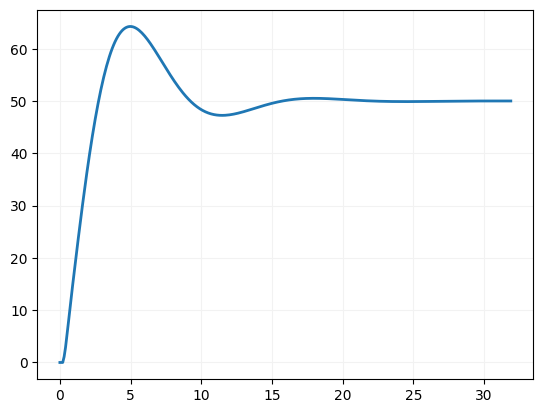

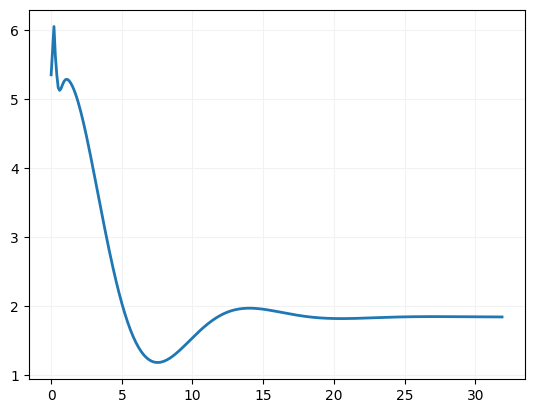

In [10]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots()
fig, ax2 = plt.subplots()

 
# Crear una instancia del controlador
controller = Controller()

# Asignar valores iniciales a las ganancias del controlador
Kp=0.1
Ki=7
Kd=0.6

# Inicializar el controlador con los valores de ganancia
controller.Init(Kp, Ki, Kd)

# inicializar parámetros
velocidad=[]
ut=[]
tiempo=[]

# Asignar el setpoint de 50 km/h
Velocidad_de_referencia = 50.0

# Establecer la velocidad de referencia en el controlador
controller.Set_reference(Velocidad_de_referencia)

# Ejecutar 320 ciclos del controlador
for ite in range(320):
    x,y = controller.Exec_controller_cycle()
    velocidad.append(x)
    ut.append(y)
    tiempo.append(ite * 0.1) # Multiplicamos por el tiempo de muestreo (0.1s)
    
# Dibujar el resultado de los 320 ciclos    
ax.plot(tiempo, velocidad, linewidth=2.0)
ax.grid(axis='x', color='0.95')
ax.grid(axis='y', color='0.95')
ax2.plot(tiempo, ut, linewidth=2.0)
ax2.grid(axis='x', color='0.95')
ax2.grid(axis='y', color='0.95')


## Análisis de las gráficas


En este ensayo simulamos la respuesta del motor ante un escalón de **referencia de 50 km/h**, aplicando un **controlador PID** con ganancias **Kp = 0.1**, **Ki = 7** y **Kd = 0.6**.
Se ejecutan **320 ciclos** con un tiempo de muestreo de **0.1 s** (equivalente a ~32 s de simulación). El objetivo es observar tanto la **respuesta en velocidad** como la **señal de control u(t)** (voltaje) que genera el PID.

### 1) Gráfica superior: Velocidad vs tiempo

### Fase de subida (respuesta rápida inicial)

* La velocidad parte desde 0 y sube con mucha rapidez hacia la referencia.
* Esta subida tan rápida se debe a que al inicio el **error es grande** (50 − 0), y por tanto el PID aplica una acción fuerte para acelerar el motor.

### Sobreimpulso (overshoot)

* Se observa que la velocidad **supera claramente los 50 km/h**, alcanzando aproximadamente un máximo alrededor de **65 km/h** (valor estimado visualmente).
* Esto implica un sobreimpulso aproximado de:
  [
  %OS \approx \frac{65-50}{50}\cdot 100 \approx 30%
  ]
* La causa típica de este sobreimpulso es un **término integral alto (Ki = 7)**, que acumula error muy rápido y puede empujar de más incluso cuando ya estamos cerca del setpoint.

### Corrección y oscilación amortiguada

* Tras el pico, la velocidad desciende por debajo de la referencia (zona ~47–48 km/h) y luego vuelve a subir.
* Se aprecia una **oscilación amortiguada**, es decir, las oscilaciones van disminuyendo con el tiempo hasta estabilizarse.
* El término derivativo (Kd) ayuda a amortiguar, pero con Ki alto todavía se nota un transitorio con oscilación.

### Régimen estacionario

* Finalmente, la velocidad converge y se mantiene cerca de **50 km/h**, por lo que el **error estacionario (Ess)** parece pequeño (cercano a 0 en el final).


La configuración logra alcanzar la referencia, pero presenta **un overshoot considerable** y muestra oscilación antes de estabilizarse.


### 2) Gráfica inferior: Señal de control u(t) vs tiempo

Esta gráfica representa el voltaje que el PID manda al motor (u(t)) en cada instante.

### Pico inicial de control

* Al principio aparece un valor alto de control (aprox. **5–6 V**).
* Esto es coherente: al inicio el **error es máximo**, por lo que el PID empuja fuerte para acelerar.

Aunque en el modelo existe saturación a ±24 V, en estas gráficas **no parece que se alcance la saturación**, ya que u(t) se queda muy por debajo de 24 V.

### Caída de u(t) tras el sobreimpulso

* Tras el pico de velocidad, la señal de control baja hasta un mínimo (~1.2 V aprox.).
* Cuando la velocidad se pasa del setpoint, el error se vuelve negativo o pequeño, y el controlador reduce el voltaje para frenar/corregir.

### Ajuste final hacia un valor estable

* Después, u(t) se recupera y se estabiliza alrededor de un valor medio (~1.8–2 V aprox.).
* Ese valor estable es el voltaje que el sistema necesita para **mantener 50 km/h** compensando pérdidas y dinámica  del motor.

La señal de control muestra el comportamiento típico: **empuje inicial fuerte**, corrección tras el sobreimpulso y finalmente un **valor estable** de mantenimiento.


## Relación entre ambas gráficas (qué nos dicen juntas)

* Cuando u(t) es alto al principio, la velocidad sube rápido.
* El **Ki alto** hace que la integral acumule error de forma agresiva, y así se genera un “empujón extra”, y aparece overshoot.
* Cuando la velocidad se pasa, el controlador baja u(t), la velocidad cae por debajo y se produce la oscilación amortiguada.
* Con el tiempo, el equilibrio entre P, I y D hace que u(t) se estabilice y la velocidad converja al setpoint.


## Conclusión

* Esta configuración **cumple** con llegar a 50 km/h y dejar Ess pequeño.
* Sin embargo, el **overshoot (~30%)** es alto.
* Para reducirlo, normalmente se:

  * **reduce Ki** (menos acumulación),
  * y/o **aumenta Kd** (más amortiguamiento),
  * y se ajusta Kp para mantener rapidez sin pasarse.



Con **Kp=0.1, Ki=7, Kd=0.6**, el sistema es rápido y llega bien a 50 km/h, pero el **Ki alto provoca un overshoot notable y oscilación amortiguada** antes de estabilizarse.


### Ejercicio 2: Con el controlador desarrollado:

    1.- Ajustar las ganancias para que el comportamiento tenga un overshoot del 10%
    2.- Ajustar las ganancias para que el tiempo de estabilización Ts sea mínimo
    3.- Ajustar las ganancias para que el error en régimen estacionario Ess sea mínimo
    4.- Ajustar las ganancias para que no haya overshoot
    5.- Ajustar las ganancias que minimicen todos los errores

### NOTAS:
Vamos a tomar como referencia las ganancias del ejercicio anterior(Kp=0.1,Ki=7,Kd=0.6) e id ajustandolo intentando llegar al objetivo de cada uno de los ejercicios.

- Kp (Proporcional): Aumenta la rapidez de respuesta, pero puede causar overshoot"

- Ki (Integral): Reduce el error en régimen estacionario, pero puede aumentar el overshoot"

- Kd (Derivativo): Reduce el overshoot y estabiliza la respuesta, pero es sensible al ruido"


En este ejercicio partimos de la configuración base del Ejercicio 1 (**Kp=0.1, Ki=7, Kd=0.6**) y fuimos ajustando **una combinación razonable de Kp, Ki y Kd** según el objetivo de cada apartado:

* **Kp (Proporcional):** acelera la respuesta (subida más rápida), pero suele aumentar el riesgo de **overshoot** y oscilaciones si es alto.
* **Ki (Integral):** reduce el **error estacionario (Ess)**, pero si es alto puede generar más overshoot y transitorio más largo (por acumulación del integrador).
* **Kd (Derivativo):** amortigua, reduce overshoot y oscilaciones, pero un Kd alto puede “frenar” demasiado y volver la respuesta más lenta o sensible a ruido.

Para comparar todos los casos usamos la misma función auxiliar `simular_pid()`, que:

1. inicializa el controlador con (Kp,Ki,Kd),
2. simula 320 ciclos,
3. dibuja **dos gráficas** por configuración:

   * **Velocidad vs ciclos** (arriba)
   * **Señal de control u(t) vs ciclos** (abajo)

En nuestro código, `ut.append(y)` guarda `new_motor_voltage = P+I+D`, es decir, **la salida calculada por el PID antes de la saturación**. Luego `Set_ea()` limita realmente el voltaje aplicado al motor a ±24 V. Por eso, en algunas figuras la curva verde puede superar 24 V, aunque el motor reciba el valor saturado.

In [26]:
from matplotlib import pyplot as plt

# Función auxiliar para ejecutar la simulación con parámetros PID específicos
def simular_pid(Kp, Ki, Kd, nombre_configuracion):
    # Crear una instancia del controlador
    controller = Controller()

    # Inicializar el controlador con los valores de ganancia
    controller.Init(Kp, Ki, Kd)

    # Inicializar parámetros
    velocidad = []
    ut = []
    coordenadax = []

    # Asignar el setpoint de 50 km/h
    Velocidad_de_referencia = 50.0

    # Establecer la velocidad de referencia en el controlador
    controller.Set_reference(Velocidad_de_referencia)

    # Ejecutar 320 ciclos del controlador (32 segundos, > 30s requeridos)
    for ite in range(320):
        x, y = controller.Exec_controller_cycle()
        velocidad.append(x)
        ut.append(y)
        coordenadax.append(ite)

    
    # Imprimir resultados
    print(f"\n=== CONFIGURACIÓN: {nombre_configuracion} ===")
    print(f"Parámetros PID: Kp={Kp}, Ki={Ki}, Kd={Kd}")
    
    # Graficar resultados
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Gráfico de velocidad
    ax1.plot(coordenadax, velocidad, linewidth=2.0, label='Velocidad actual')
    ax1.axhline(y=Velocidad_de_referencia, color='red', linestyle='--', label='Referencia (50 km/h)')
    ax1.set_title(f'Respuesta de Velocidad - {nombre_configuracion}')
    ax1.set_ylabel('Velocidad (km/h)')
    ax1.grid(axis='x', color='0.95')
    ax1.grid(axis='y', color='0.95')
    ax1.legend()
    
    # Gráfico de señal de control
    ax2.plot(coordenadax, ut, linewidth=2.0, color='green', label='Señal de control (V)')
    ax2.axhline(y=24, color='red', linestyle=':', label='Límite superior (24V)')
    ax2.axhline(y=-24, color='red', linestyle=':', label='Límite inferior (-24V)')
    ax2.set_title(f'Señal de Control - {nombre_configuracion}')
    ax2.set_xlabel('Ciclos de control (1 ciclo = 0.1s)')
    ax2.set_ylabel('Voltaje (V)')
    ax2.grid(axis='x', color='0.95')
    ax2.grid(axis='y', color='0.95')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    


===== OBJETIVO 1: OVERSHOOT DEL 10% =====

=== CONFIGURACIÓN: Overshoot del 10% ===
Parámetros PID: Kp=0.1, Ki=3, Kd=0.6


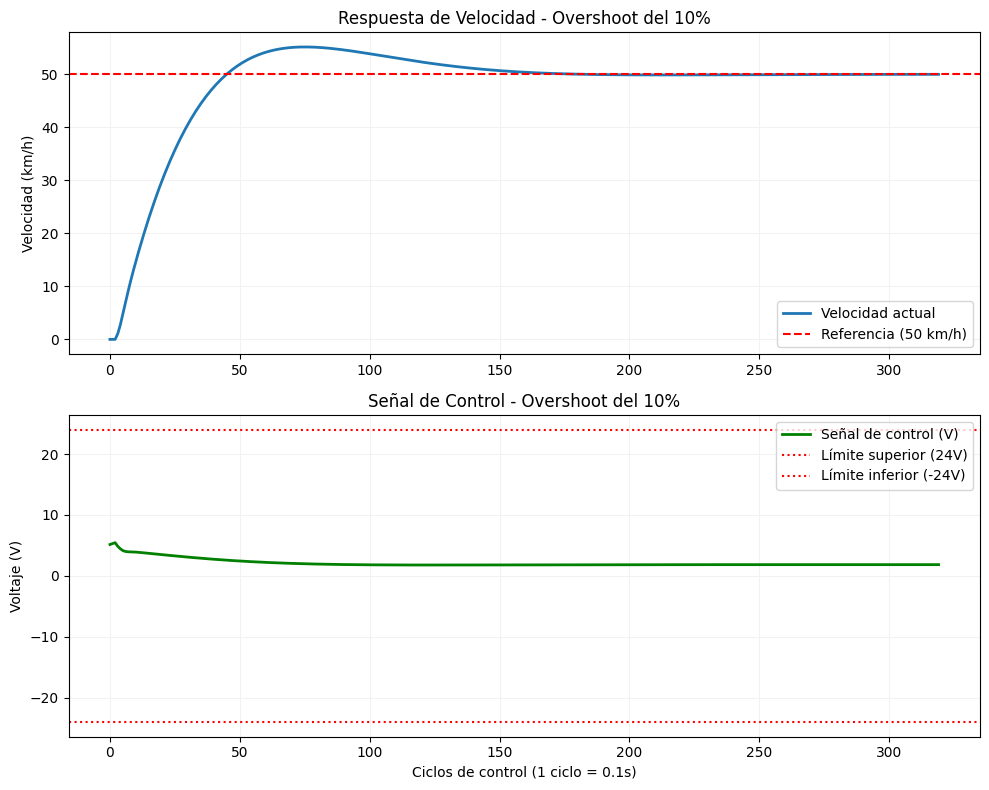

In [ ]:
# 1. Ajuste para overshoot del 10%

# Kp=0.1,Ki=7,Kd=0.6
# Como un alto Ki puede aumentar el sobreimpulso, se ajustan los parámetros para lograr aproximadamente un 10% de overshoot.
print("\n===== OBJETIVO 1: OVERSHOOT DEL 10% =====")
# Parámetros ajustados para ~10% de sobreimpulso
Kp_1 = 0.1
Ki_1 = 3
Kd_1 = 0.6
simular_pid(Kp_1, Ki_1, Kd_1, "Overshoot del 10%")


### Objetivo 1 — Overshoot ≈ 10%

**Ganancias elegidas:** `Kp=0.1, Ki=3, Kd=0.6`


### Interpretación de la velocidad

* La curva sube de forma progresiva y **supera ligeramente** la referencia de 50 km/h.
* El pico máximo está alrededor de **55 km/h**, que corresponde aproximadamente a un **10% de overshoot**.
* Después, la velocidad vuelve hacia 50 km/h con una corrección suave, sin grandes oscilaciones.

### Interpretación de u(t)

* u(t) comienza relativamente alta (impulso inicial para acelerar) y luego **desciende** hacia un valor casi constante de mantenimiento.
* No se observan oscilaciones agresivas en la señal, lo cual nos dice que s etrata de un sistema **bien amortiguado**.

### Por qué estos valores ayudan

* **Reducimos Ki** de 7 a 3 para evitar acumulación excesiva del integrador (menos empuje extra cerca del setpoint).
* Mantener **Kd=0.6** ayuda a amortiguar.
* Dejar **Kp=0.1** conserva una subida razonable sin disparar el overshoot.



===== OBJETIVO 2: TIEMPO DE ESTABILIZACIÓN MÍNIMO =====

=== CONFIGURACIÓN: Tiempo de Estabilización Mínimo ===
Parámetros PID: Kp=1, Ki=3, Kd=0.6


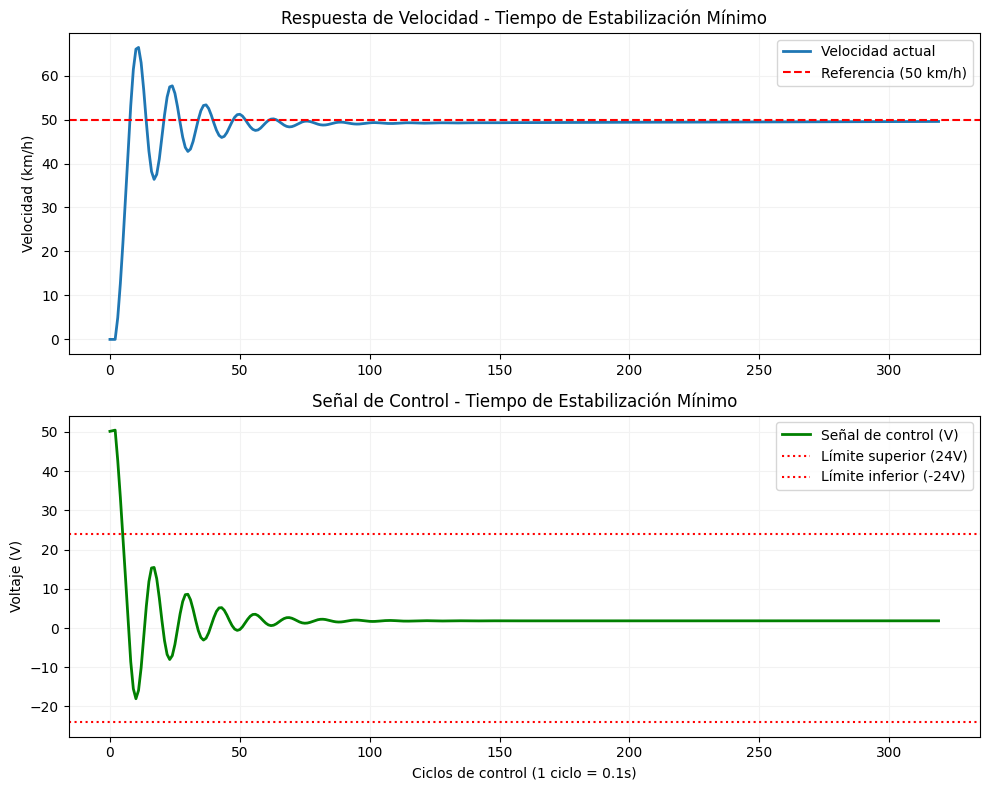

In [ ]:
# 2. Ajuste para tiempo de estabilización (Ts) mínimo

# Kp=0.1,Ki=7,Kd=0.6
# Kp más alto y un Ki moderado pueden reducir el tiempo de estabilización, pero hay que evitar un Ki demasiado alto para no aumentar el overshoot.
print("\n===== OBJETIVO 2: TIEMPO DE ESTABILIZACIÓN MÍNIMO =====")
# Parámetros ajustados para Ts mínimo (respuesta rápida)
Kp_2 = 1
Ki_2 = 3
Kd_2 = 0.6
simular_pid(Kp_2, Ki_2, Kd_2, "Tiempo de Estabilización Mínimo")



### Objetivo 2 — Tiempo de estabilización Ts mínimo

**Ganancias elegidas:** `Kp=1, Ki=3, Kd=0.6`

### Interpretación de la velocidad

* La velocidad sube **muy rápido** (respuesta muy agresiva).
* Aparecen **oscilaciones claras** alrededor de 50 km/h al principio.
* Aunque oscila, esas oscilaciones se amortiguan relativamente pronto, logrando estabilizarse en menos tiempo que configuraciones más suaves.

### Interpretación de u(t)

* Se ve una acción de control con **picos grandes** (incluso por encima de 24 V en la gráfica, recordando que eso es el valor calculado).
* Esto indica que el controlador “exige” un esfuerzo grande al principio para llegar cuanto antes a la referencia.
* La señal alterna (positiva/negativa) al corregir el sobrepaso, lo que explica la oscilación de la velocidad.

### Por qué estos valores ayudan 

* Subir **Kp a 1** aumenta muchísimo la rapidez. que tiende a reducir Ts, pero:

  * incrementa overshoot y oscilación si el amortiguamiento no es suficiente.
* **Ki=3** mantiene corrección del error sin hacer el integrador demasiado agresivo.
* **Kd=0.6** intenta amortiguar, pero con un Kp tan alto aún aparecen oscilaciones.


===== OBJETIVO 3: ERROR EN RÉGIMEN ESTACIONARIO MÍNIMO =====

=== CONFIGURACIÓN: Error en Régimen Estacionario Mínimo ===
Parámetros PID: Kp=0.1, Ki=5, Kd=0.6


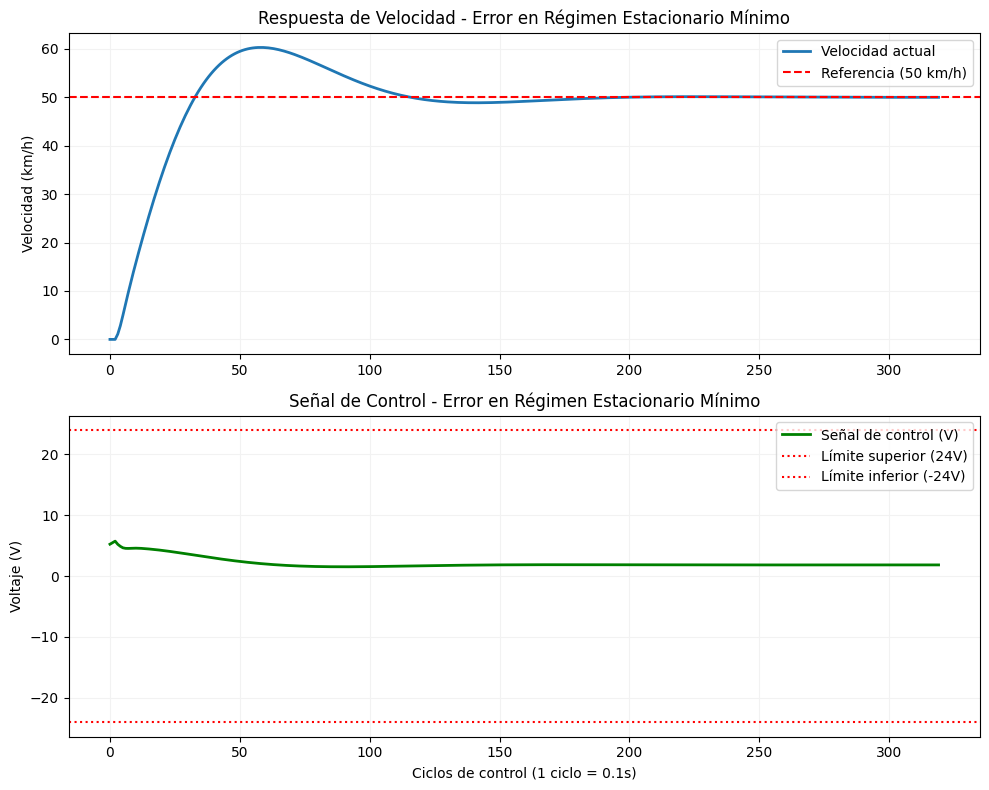

In [ ]:
# 3. Ajuste para error en régimen estacionbario (Ess) mínimo

#Kp=0.1,Ki=7,Kd=0.6
# Un Ki alto es clave para reducir el error en régimen estacionario, pero hay que balancearlo para no aumentar demasiado el overshoot o el tiempo de estabilización.
print("\n===== OBJETIVO 3: ERROR EN RÉGIMEN ESTACIONARIO MÍNIMO =====")
# Parámetros ajustados para Ess mínimo (alta ganancia integral)
Kp_3 = 0.1
Ki_3 = 5
Kd_3 = 0.6
simular_pid(Kp_3, Ki_3, Kd_3, "Error en Régimen Estacionario Mínimo")


### Objetivo 3 — Error estacionario Ess mínimo

**Ganancias elegidas:** `Kp=0.1, Ki=5, Kd=0.6`

### Interpretación de la velocidad

* Se observa un overshoot moderado (sube por encima de 50 km/h), y después vuelve lentamente hacia la referencia.
* Lo más importante en este apartado es que al final la velocidad queda **muy pegada a 50 km/h**, lo que implica **Ess muy pequeño**.

### Interpretación de u(t)

* La señal tiene un empuje inicial, luego cae y se va ajustando hacia un valor estable.
* Al tener un **Ki más alto**, el controlador “no se rinde” hasta eliminar el error, por eso el valor final queda muy cerca del setpoint.

### Por qué estos valores ayudan

* Subimos **Ki a 5** para que el integrador acumule suficiente corrección y elimine el error estacionario.
* Mantener **Kp bajo** evita que la subida sea excesivamente agresiva.
* **Kd** ayuda a controlar el sobreimpulso, aunque con Ki más alto todavía aparece cierto overshoot.


===== OBJETIVO 4: SIN OVERSHOOT =====

=== CONFIGURACIÓN: Sin Overshoot ===
Parámetros PID: Kp=0.1, Ki=1, Kd=1


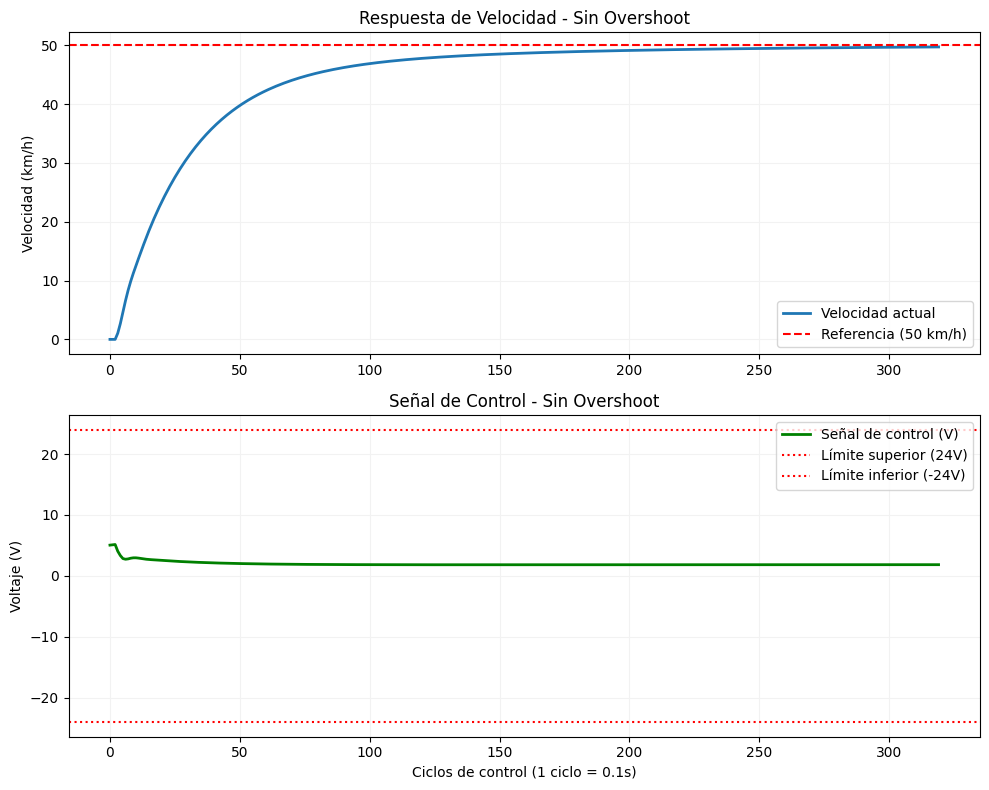

In [ ]:
# 4. Ajuste para sin overshoot

#Kp=0.1,Ki=7,Kd=0.6
# Para eliminar el overshoot, se puede reducir Kp y aumentar Kd para mejorar la estabilidad, mientras se mantiene un Ki moderado para no afectar el tiempo de estabilización.
print("\n===== OBJETIVO 4: SIN OVERSHOOT =====")
# Parámetros ajustados para cero sobreimpulso
Kp_4 = 0.1
Ki_4 = 1
Kd_4 = 1
simular_pid(Kp_4, Ki_4, Kd_4, "Sin Overshoot")

### Objetivo 4 — Sin overshoot

**Ganancias elegidas:** `Kp=0.1, Ki=1, Kd=1`

### Interpretación de la velocidad

* La velocidad sube de manera **monótona** (sin pasar de 50 km/h).
* No hay pico por encima de la referencia.
* A cambio, la respuesta es **más lenta**: tarda más en llegar cerca de 50 km/h comparado con configuraciones más agresivas.

### Interpretación de u(t)

* La señal de control es suave, sin picos grandes y sin oscilaciones importantes.
* Esto refleja un controlador con comportamiento **muy amortiguado**.

### Por qué estos valores ayudan

* **Bajamos Ki a 1**, reduciendo mucho el efecto acumulativo que suele generar overshoot.
* **Subimos Kd a 1** para aumentar el amortiguamiento (frena un poco los cambios rápidos).
* Conservamos **Kp=0.1** para no acelerar demasiado el sistema.



===== OBJETIVO 5: MINIMIZAR TODOS LOS ERRORES (COMPROMISO ÓPTIMO) =====

=== CONFIGURACIÓN: Compromiso Óptimo (Todos los Índices) ===
Parámetros PID: Kp=0.7, Ki=0.8, Kd=0.5


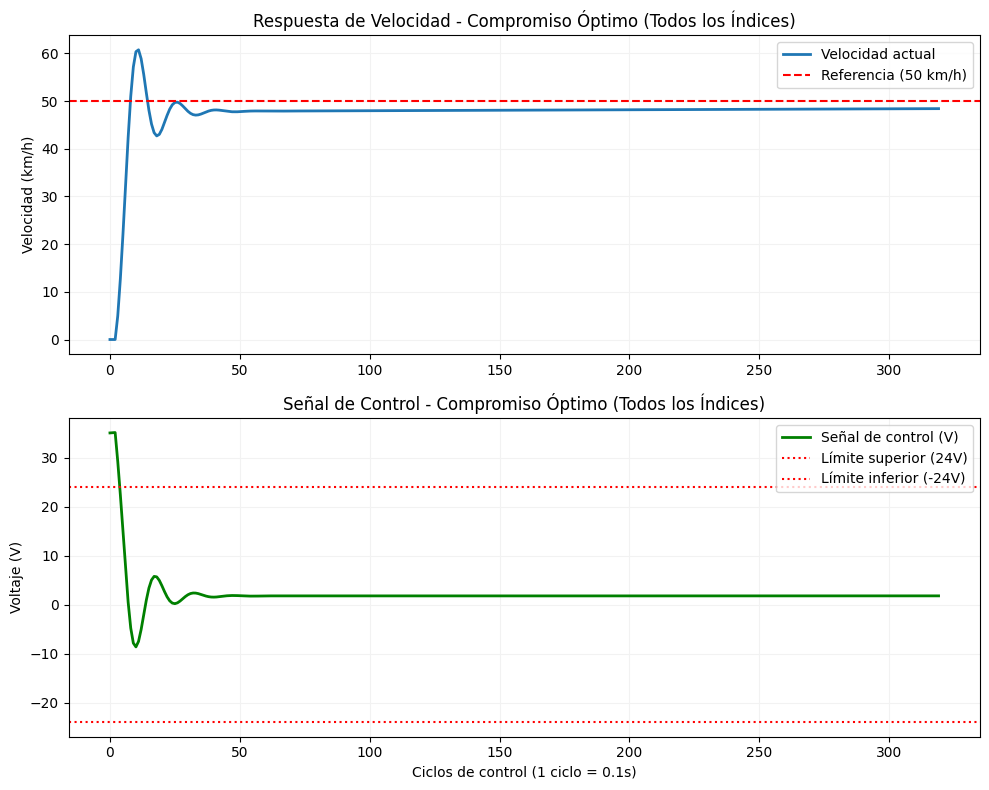

In [ ]:
# 5. Ajuste para minimizar todos los errores (compromiso óptimo)

#Kp=0.1,Ki=7,Kd=0.6
# Para lograr un compromiso óptimo entre tiempo de estabilización, overshoot y error en régimen estacionario, se pueden ajustar los parámetros para obtener un rendimiento equilibrado en todos los aspectos.
print("\n===== OBJETIVO 5: MINIMIZAR TODOS LOS ERRORES (COMPROMISO ÓPTIMO) =====")
# Parámetros balanceados para rendimiento general óptimo
Kp_5 = 0.7
Ki_5 = 0.8
Kd_5 = 0.5
simular_pid(Kp_5, Ki_5, Kd_5, "Compromiso Óptimo (Todos los Índices)")

### Objetivo 5 — Compromiso óptimo (minimizar “todos” los errores)

**Ganancias iniciales elegidas:** `Kp=0.7, Ki=0.8, Kd=0.5`

### Interpretación de la velocidad

* La subida es rápida, pero aparece un **overshoot notable** (pico por encima de 50 km/h).
* Luego se ven pequeñas oscilaciones y finalmente se estabiliza cerca de la referencia.
* En esta configuración, mejora rapidez, pero penaliza overshoot/estabilidad.

### Interpretación de u(t)

* u(t) presenta un **pico inicial muy alto** (en la gráfica se ve por encima del límite).
* Después hay una corrección fuerte (incluso negativa) y se amortigua hacia un valor estable.
* Este patrón indica un controlador relativamente agresivo al inicio, intentando llegar rápido y corrigiendo después el exceso.

### Por qué pasa esto

* **Kp=0.7** es bastante alto: acelera, pero dispara el overshoot.
* **Ki=0.8** es bajo (bien para no generar windup), pero aún así el gran Kp domina.
* **Kd=0.5** amortigua algo, pero no lo suficiente para “frenar” el efecto de Kp en el pico.

## Conclusión de este apartado

De los cinco casos, este fue el que más nos costó ajustar porque el “compromiso” exige equilibrar objetivos que compiten entre sí:

* si subimos Kp para rapidez, crece overshoot,
* si subimos Kd para frenar, puede empeorar la velocidad de subida,
* si subimos Ki para Ess, uede empeorar overshoot/Ts.

Por eso, tras ver que este caso no cumplía bien la idea de “equilibrado”, decidimos en la práctica **seguir ajustándolo** (como hacemos después en el Ejercicio 3).

### Ejercicio 3: Comprobación de los índices de rendimiento.
Implementar una función que devuelva los 4 índices de rendimiento más relevantes: Overshoot, Ess, Ts y d.
Una vez implementada esta clase, se obtendrán los índices de rendimiento para las 5 configuraciones de ganancias del Ejercicio 2

En este ejercicio el objetivo fue **cuantificar** lo que habíamos observado “a ojo” en las gráficas del Ejercicio 2. Para ello implementamos una clase `Performance` capaz de calcular los **4 índices de rendimiento** más relevantes en un control clásico:

* **Overshoot (%)**: sobreimpulso máximo respecto a la referencia.
* **Ess (km/h)**: error en régimen estacionario.
* **Ts (ciclos)**: tiempo de estabilización (entrada y permanencia dentro de una banda del 2%).
* **d (ciclos)**: tiempo de retardo (cuando se alcanza el 50% de la referencia).

Una vez implementados, calculamos estos índices para las **5 configuraciones** del Ejercicio 2 y, al ver que la configuración 5 no quedaba equilibrada, **la reajustamos**.

In [12]:

import numpy as np
import statistics as stat

class Performance:    
    def __init__(self):
        self.Overshoot = 0.0
        self.d = 0.0
        self.Ess = 0.0
        self.Ts = 0.0
        self.v = []
        self.VR = 0.0

    def Init(self, velocidades, Velocidad_de_referencia):
        self.Overshoot = 0.0
        self.d = 0.0
        self.Ess = 0.0
        self.Ts = 0.0
        self.v = velocidades
        self.VR = Velocidad_de_referencia
        
    def Calcula_indexes(self):
        # 1. Overshoot (Sobreimpulso máximo en %)
        max_v = max(self.v)
        if max_v > self.VR:
            self.Overshoot = ((max_v - self.VR) / self.VR) * 100.0
        else:
            self.Overshoot = 0.0
            
        # 2. Ess (Error en régimen estacionario al final del ensayo)
        self.Ess = abs(self.VR - self.v[-1])
        
        # 3. Ts (Tiempo de estabilización - iteración donde entra en banda del 2%)
        banda = 0.02 * self.VR  # Banda del 2% (ej: +/- 1 km/h si VR es 50)
        settled_index = len(self.v) - 1
        for i in range(len(self.v) - 1, -1, -1):
            if abs(self.v[i] - self.VR) > banda:
                settled_index = i
                break
        self.Ts = settled_index
        
        # 4. d (Tiempo de retardo - iteración donde alcanza el 50% de la referencia)
        self.d = 0.0
        for i, val in enumerate(self.v):
            if val >= (0.5 * self.VR):
                self.d = i
                break

        return self.Overshoot, self.d, self.Ess, self.Ts


## Implementación de la clase `Performance`

### Estructura y propósito

Creamos la clase `Performance` para separar dos cosas:

* **Simulación** (obtener `velocidad[]` con el PID).
* **Evaluación** (calcular métricas sobre `velocidad[]`).

Esto nos permitió comparar configuraciones de forma objetiva.

La clase guarda:

* `self.v`: lista de velocidades simuladas.
* `self.VR`: velocidad de referencia (50 km/h).
* y los índices: `Overshoot`, `Ess`, `Ts`, `d`.

### Inicialización (`Init`)

En `Init()` reiniciamos las métricas a cero y guardamos:

* la señal medida `velocidades`
* la referencia `Velocidad_de_referencia`

Así evitamos que queden valores “arrastrados” de simulaciones anteriores.


## Cálculo de índices (`Calcula_indexes`) 

### Overshoot (%)

Medimos el máximo pico por encima de la referencia.

* Tomamos `max_v = max(self.v)`.
* Si `max_v > VR`, calculamos:
$$
Overshoot(\%) = \frac{max\_v - VR}{VR}\cdot 100
$$
* Si no se supera la referencia, Overshoot = 0.

Mide lo pasado que se va el sistema al responder al escalón.



### Ess (Error en régimen estacionario)

Medimos el error al final del ensayo (último valor simulado).

$$
Ess = |VR - v[-1]|
$$

Si Ess es cercano a 0, la salida queda igual a la referencia.



### Ts (Tiempo de estabilización) usando banda del 2%

Medimos cuándo el sistema entra en una banda del ±2% y ya no vuelve a salir.

* Calculamos la banda:
  `banda = 0.02 * VR` con VR=50, banda = 1 km/h.
* Recorremos la señal desde el final hacia atrás buscando el último punto que se sale de la banda.
* Ese índice se guarda como `Ts`.

Cuanto menor Ts, antes se estabiliza la respuesta.

Ts lo damos en **ciclos**. Si lo quisieramos en segundos:
$$
Ts(s) = Ts(ciclos)\cdot 0.1
$$



### Tiempo de retardo

Medimos cuándo se alcanza por primera vez el 50% de la referencia.

* Umbral: `0.5*VR = 25 km/h`
* Buscamos el primer índice `i` donde `v[i] >= 25`.

Mide “lo rápido que arranca” el sistema tras el escalón.


## Comprobación automática para las 5 configuraciones (Ejercicio 2)

Para validar la clase, redefinimos una función `simular_pid_y_rendimiento()` que:

1. simula la velocidad con un PID (320 ciclos),
2. calcula índices con `Performance`,
3. imprime resultados,
4. dibuja las gráficas para comparar visualmente.

Después creamos una lista `configuraciones` con las 5 combinaciones del Ejercicio 2 y las evaluamos en un bucle.

Para probar el ejercicio 3 se ejecutará el siguiente código:

## 4) Resultados y análisis 

COMPROBACIÓN DE LOS ÍNDICES DE RENDIMIENTO (EJERCICIO 3)

=== 1. OVERSHOOT DEL 10% ===
Parámetros: Kp=0.1, Ki=3, Kd=0.6
  -> Overshoot: 10.33 %
  -> Tiempo de retardo (d): 17 ciclos
  -> Error en régimen estacionario (Ess): 0.0004 km/h
  -> Tiempo de estabilización (Ts): 142 ciclos


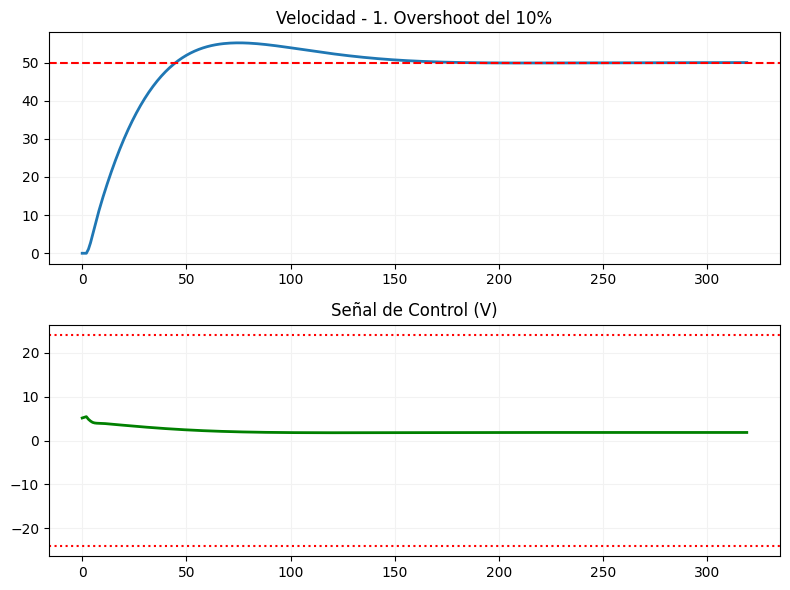


=== 2. TIEMPO DE ESTABILIZACIÓN (TS) MÍNIMO ===
Parámetros: Kp=1, Ki=3, Kd=0.6
  -> Overshoot: 32.80 %
  -> Tiempo de retardo (d): 6 ciclos
  -> Error en régimen estacionario (Ess): 0.4385 km/h
  -> Tiempo de estabilización (Ts): 96 ciclos


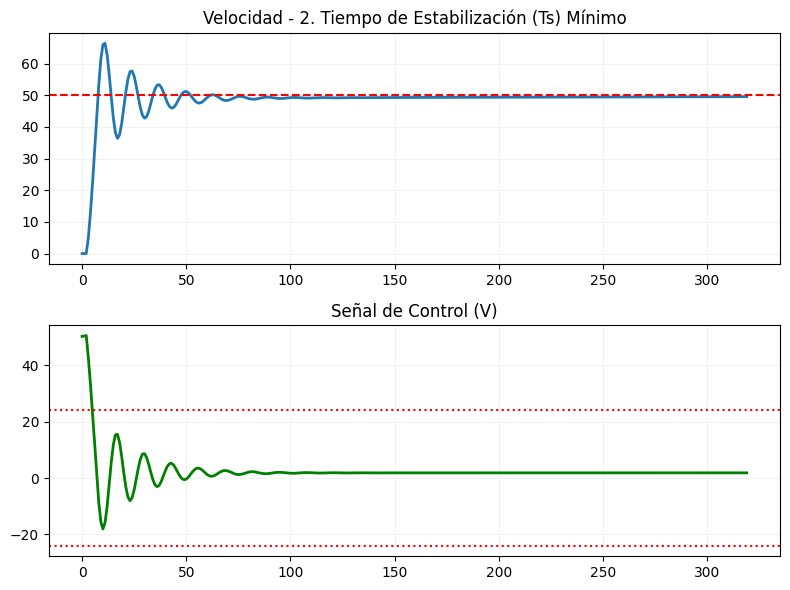


=== 3. ERROR ESTACIONARIO (ESS) MÍNIMO ===
Parámetros: Kp=0.1, Ki=5, Kd=0.6
  -> Overshoot: 20.59 %
  -> Tiempo de retardo (d): 15 ciclos
  -> Error en régimen estacionario (Ess): 0.0121 km/h
  -> Tiempo de estabilización (Ts): 152 ciclos


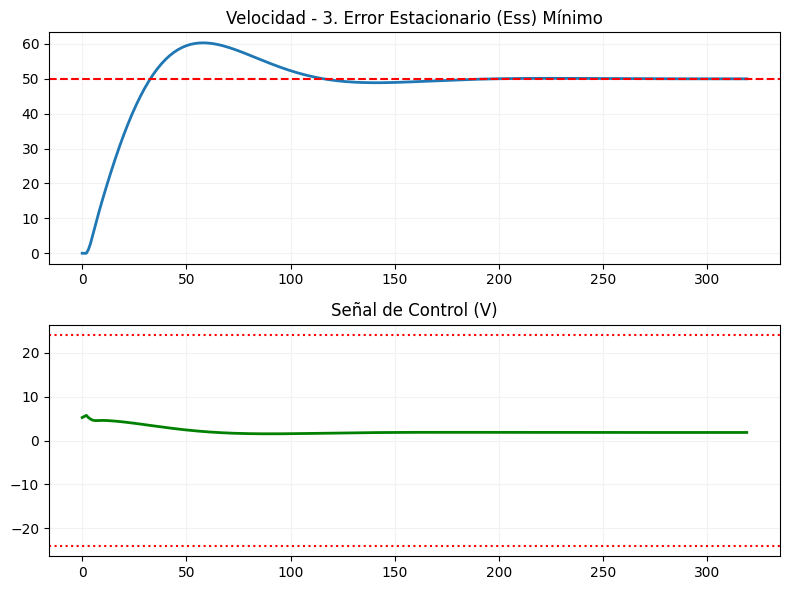


=== 4. SIN OVERSHOOT ===
Parámetros: Kp=0.1, Ki=1, Kd=1
  -> Overshoot: 0.00 %
  -> Tiempo de retardo (d): 22 ciclos
  -> Error en régimen estacionario (Ess): 0.2896 km/h
  -> Tiempo de estabilización (Ts): 187 ciclos


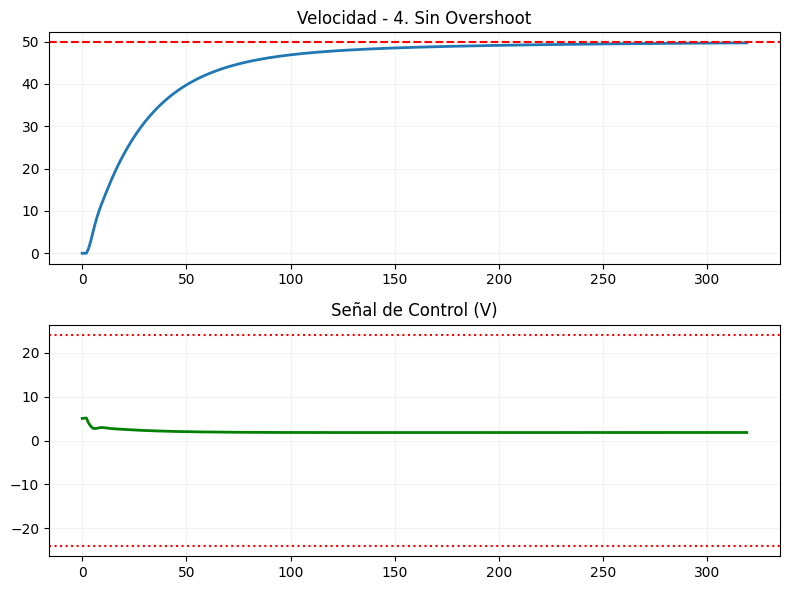


=== 5. COMPROMISO ÓPTIMO (MINIMIZAR TODOS) ===
Parámetros: Kp=0.7, Ki=0.8, Kd=0.5
  -> Overshoot: 21.46 %
  -> Tiempo de retardo (d): 6 ciclos
  -> Error en régimen estacionario (Ess): 1.6022 km/h
  -> Tiempo de estabilización (Ts): 319 ciclos


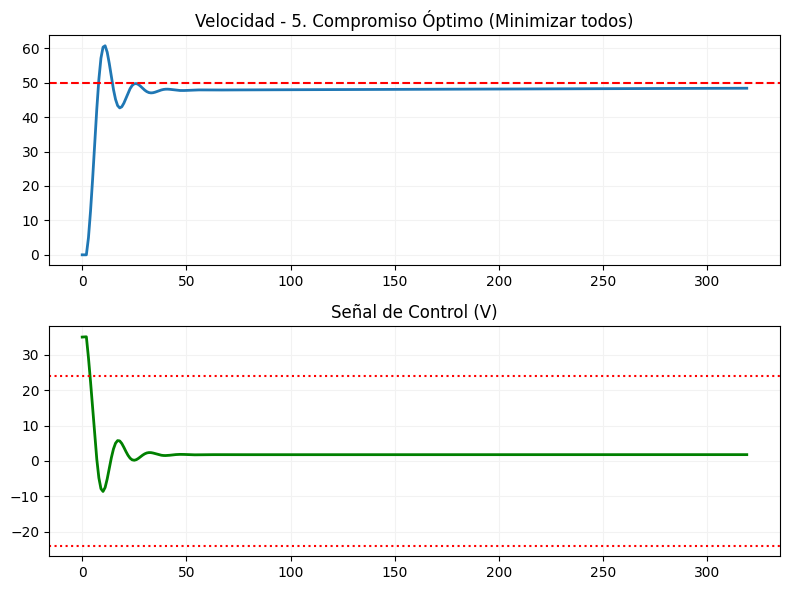

In [ ]:
from matplotlib import pyplot as plt

# 1. Redefinimos la función auxiliar para que incluya el cálculo de rendimiento
def simular_pid_y_rendimiento(Kp, Ki, Kd, nombre_configuracion):
    # Crear e inicializar el controlador
    controller = Controller()
    controller.Init(Kp, Ki, Kd)

    velocidad = []
    ut = []
    coordenadax = []
    Velocidad_de_referencia = 50.0
    controller.Set_reference(Velocidad_de_referencia)

    # Ejecutar 320 ciclos del controlador
    for ite in range(320):
        x, y = controller.Exec_controller_cycle()
        velocidad.append(x)
        ut.append(y)
        coordenadax.append(ite)

    P = Performance()   
    P.Init(velocidad, Velocidad_de_referencia)
    Overshoot, d, Ess, Ts = P.Calcula_indexes()
    
    # Imprimir los resultados por pantalla
    print(f"\n=== {nombre_configuracion.upper()} ===")
    print(f"Parámetros: Kp={Kp}, Ki={Ki}, Kd={Kd}")
    print(f"  -> Overshoot: {Overshoot:.2f} %")
    print(f"  -> Tiempo de retardo (d): {d} ciclos")
    print(f"  -> Error en régimen estacionario (Ess): {Ess:.4f} km/h")
    print(f"  -> Tiempo de estabilización (Ts): {Ts} ciclos")
    
    # Graficar resultados (Opcional, pero recomendado para verlo)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    
    ax1.plot(coordenadax, velocidad, linewidth=2.0)
    ax1.axhline(y=Velocidad_de_referencia, color='red', linestyle='--')
    ax1.set_title(f'Velocidad - {nombre_configuracion}')
    ax1.grid(axis='both', color='0.95')
    
    ax2.plot(coordenadax, ut, linewidth=2.0, color='green')
    ax2.axhline(y=24, color='red', linestyle=':')
    ax2.axhline(y=-24, color='red', linestyle=':')
    ax2.set_title('Señal de Control (V)')
    ax2.grid(axis='both', color='0.95')
    
    plt.tight_layout()
    plt.show()

# 2. Lista con las 5 configuraciones del Ejercicio 2
configuraciones = [
    ["1. Overshoot del 10%", 0.1, 3, 0.6],
    ["2. Tiempo de Estabilización (Ts) Mínimo", 1, 3, 0.6],
    ["3. Error Estacionario (Ess) Mínimo", 0.1, 5, 0.6],
    ["4. Sin Overshoot", 0.1, 1, 1],
    ["5. Compromiso Óptimo (Minimizar todos)", 0.7, 0.8, 0.5]
]

# 3. Bucle para probar y obtener los índices de rendimiento de las 5 configuraciones
print("COMPROBACIÓN DE LOS ÍNDICES DE RENDIMIENTO (EJERCICIO 3)\n" + "="*55)

for config in configuraciones:
    nombre = config[0]
    kp_val = config[1]
    ki_val = config[2]
    kd_val = config[3]
    
    # Llamamos a la función que simula y calcula los índices
    simular_pid_y_rendimiento(kp_val, ki_val, kd_val, nombre)

### Configuración 1 — Overshoot del 10% (Kp=0.1, Ki=3, Kd=0.6)

**Resultados:**

* Overshoot: **10.33 %**
* d: **17 ciclos**
* Ess: **0.0004 km/h**
* Ts: **142 ciclos**

**Análisis de la gráfica:**

* Cumple el objetivo: sobreimpulso alrededor del 10%.
* Es bastante estable, pero no es la más rápida: Ts es medio-alto (142 ciclos ≈ 14.2 s).
* Ess prácticamente cero, al final queda clavada en 50 km/h.


### Configuración 2 — Ts mínimo (Kp=1, Ki=3, Kd=0.6)

**Resultados:**

* Overshoot: **32.80 %**
* d: **6 ciclos**
* Ess: **0.4385 km/h**
* Ts: **96 ciclos**

**Análisis de la gráfica:**

* Es la más “agresiva”: llega muy rápido (d=6 ciclos ≈ 0.6 s).
* Reduce Ts a 96 ciclos (~9.6 s), que es el menor entre las 5 originales.
* El precio a pagar es grande: **mucho overshoot** (~33%) y más oscilación.
* Ess no es enorme, pero no queda tan perfecto como en otras.


### Configuración 3 — Ess mínimo (Kp=0.1, Ki=5, Kd=0.6)

**Resultados:**

* Overshoot: **20.59 %**
* d: **15 ciclos**
* Ess: **0.0121 km/h**
* Ts: **152 ciclos**

**Análisis de la gráfica:**

* Ess es muy bajo (casi cero), o sea, el integrador corrige bien al final.
* A cambio, sube el overshoot (~21%) y Ts aumenta (15.2 s).
* Esta configuración cumple “Ess mínimo”, pero sacrifica rapidez y overshoot.



### Configuración 4 — Sin overshoot (Kp=0.1, Ki=1, Kd=1)

**Resultados:**

* Overshoot: **0.00 %**
* d: **22 ciclos**
* Ess: **0.2896 km/h**
* Ts: **187 ciclos**

**Análisis de la gráfica:**

* Objetivo logrado: no hay sobreimpulso.
* Pero la respuesta es la más lenta: d y Ts son los más altos (18.7 s).
* Ess es mayor que en otras: al final queda un pequeño error (no llega tan “clavado” a 50).


### Configuración 5 — Compromiso óptimo (Kp=0.7, Ki=0.8, Kd=0.5)

**Resultados:**

* Overshoot: **21.46 %**
* d: **6 ciclos**
* Ess: **1.6022 km/h**
* Ts: **319 ciclos**

**Análisis de la gráfica:**

* Aunque arranca rápido (d=6), el resultado no es buen compromiso:

  * overshoot alto (~21%),
  * Ess muy alto (1.6 km/h),
  * Ts casi al máximo del ensayo (319 ciclos ≈ 31.9 s), lo que indica que tarda mucho en quedar dentro de la banda del 2%.
* Esta fue la única que claramente no cumplía “compromiso” y por eso la reajustamos.


Podemos comprobar que menos la actividad 5 , todas las demás cumplen mas o menos con lo pedido , por lo que ahora vamos a intentar ajustar la 5 para que cumpla con los requisitos.

Overshoot:  1.144856436939861
d:  10
Ess:  0.01569642604017929
Ts: 39


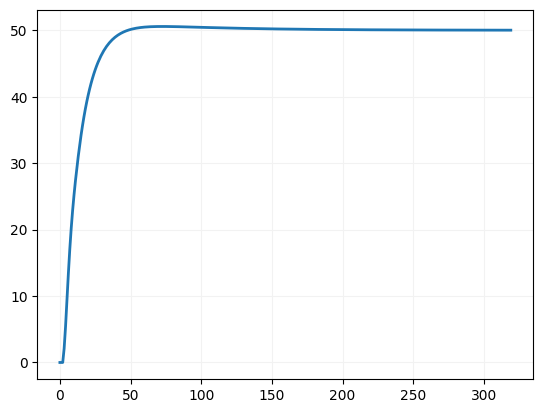

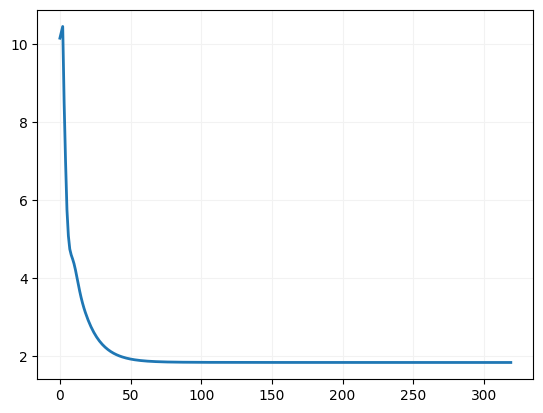

In [41]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots()
fig, ax2 = plt.subplots()

 
# Crear una instancia del controlador
controller = Controller()

# Asignar valores iniciales a las ganancias del controlador
Kp=0.2
Ki=3
Kd=0.8

# Inicializar el controlador con los valores de ganancia
controller.Init(Kp, Ki, Kd)

# inicializar parámetros
velocidad=[]
ut=[]
coordenadax=[]

# Asignar el setpoint de 50 km/h
Velocidad_de_referencia = 50.0

# Establecer la velocidad de referencia en el controlador
controller.Set_reference(Velocidad_de_referencia)

# Ejecutar 320 ciclos del controlador
for ite in range(320):
    x,y = controller.Exec_controller_cycle()
    velocidad.append(x)
    ut.append(y)
    coordenadax.append(ite)

# Calcular los índices de rendimiento
P = Performance()   
P.Init(velocidad, Velocidad_de_referencia)
o, d, Ess, Ts = P.Calcula_indexes()
print("Overshoot: ",o)
print("d: ",d)
print("Ess: ",Ess)
print("Ts:", Ts)
    
# Dibujar el resultado de los 320 ciclos    
ax.plot(coordenadax, velocidad, linewidth=2.0)
ax.grid(axis='x', color='0.95')
ax.grid(axis='y', color='0.95')
ax2.plot(coordenadax, ut, linewidth=2.0)
ax2.grid(axis='x', color='0.95')
ax2.grid(axis='y', color='0.95')


## Reajuste de la Configuración 5 (mejor compromiso real)

Viendo los resultados, intentamos corregir la configuración 5 buscando:

* overshoot bajo,
* Ts bajo,
* Ess pequeño,
* y sin acciones excesivamente agresivas.

**Nueva propuesta probada: Kp=0.2, Ki=3, Kd=0.8**

**Resultados (6ª y 7ª imagen):**

* Overshoot: **1.1449 %**
* d: **10 ciclos**
* Ess: **0.0157 km/h**
* Ts: **39 ciclos**

**Interpretación humana:**

* Overshoot prácticamente eliminado (≈1%).
* Ts cae muchísimo: 39 ciclos (**3.9 s**) (muy rápido).
* Ess es muy bajo (0.016 km/h), prácticamente clavado.
* d=10 ciclos (1 s), sigue siendo rápido sin ser tan agresivo como el caso Kp=1.


Esta nueva configuración sí se comporta como un “compromiso óptimo” real: es rápida, estable, con muy poco overshoot y error final casi nulo.


## Conclusión final del Ejercicio 3

Como equipo, este ejercicio nos sirvió para:

1. pasar de “ver gráficas” a **medir con números**;
2. comprobar que cada objetivo del Ejercicio 2 se refleja claramente en los índices;
3. detectar objetivamente que la configuración 5 inicial no era buen compromiso;
4. reajustarla hasta conseguir un comportamiento equilibrado (Kp=0.2, Ki=3, Kd=0.8) con índices muy buenos.

